# 🌲 06 — Random Forest Model Training & Evaluation

This notebook trains **Random Forest** models for regression and classification on the model-ready air quality dataset. 

### 🧒 Easy guide (Inputs & Outputs)
- **Input:** data files in `data/processed/` (train/val/test or full dataset).
- Each row is one forest plot. **Features** are clues; the **target** is the answer.
- **Output:** trained models saved in `outputs/models/`, scores saved in `outputs/reports/`, and plots shown on screen.
- **Random Forest** means many small trees vote on the answer.

### ✅ If accuracy is 1.0 (overfitting)
Random Forest **does not use epochs**. To make it less perfect on training data, we make trees smaller:
- reduce `max_depth`
- increase `min_samples_leaf`
- increase `min_samples_split`
- reduce `n_estimators`

## 0. Setup & Imports

This cell sets up the folder and helps Colab users download the project.

In [2]:
# ── Google Colab & Local auto-setup ─────────────────────────────────────────-

import os, sys



# 1. FIX WORKING DIRECTORY (Crucial for VS Code)

# If running from notebooks/ subdir, move up to repo root

if os.path.basename(os.getcwd()) == 'notebooks':

    os.chdir('..')



# Ensure repo root is in sys.path so 'src' is importable

repo_root = os.getcwd()

if repo_root not in sys.path:

    sys.path.insert(0, repo_root)



# 2. GOOGLE COLAB WORKFLOW

if 'google.colab' in sys.modules:

    REPO_DIR = 'Air_Quality_Predictor'

    # Clone the repo if not already done

    if not os.path.exists(REPO_DIR):

        !git clone https://github.com/shashi2024/Air_Quality_Predictor.git

    os.chdir(REPO_DIR)



    # Install dependencies

    !pip install -r requirements.txt -q



    # Run the data pipeline notebooks (01-05) if processed data doesn't exist

    import subprocess

    data_ready = (

        os.path.exists(os.path.join('data', 'processed', 'train.parquet')) or

        os.path.exists(os.path.join('data', 'processed', 'train.csv'))

    )

    if not data_ready:

        print('⏳ Running data pipeline notebooks 01-05... (this may take 10-20 minutes)')

        for nb_name in [

            '01_data_ingestion', '02_eda_exploration', '03_preprocessing',

            '04_feature_extraction', '05_model_ready_dataset'

        ]:

            nb_path = os.path.join('notebooks', f'{nb_name}.ipynb')

            print(f'   ▶ Running {nb_name}.ipynb ...')

            result = subprocess.run(

                ['jupyter', 'nbconvert', '--to', 'notebook', '--execute',

                 '--ExecutePreprocessor.timeout=1800',

                 '--ExecutePreprocessor.kernel_name=python3',

                 nb_path, '--output', nb_path],

                capture_output=True, text=True

            )

            if result.returncode != 0:

                print(f'   ⚠️  {nb_name} had warnings/errors\n{result.stderr[-300:]}')

            else:

                print(f'   ✅ {nb_name} done')

        print('✅ Data pipeline complete!')

    else:

        print('✅ Processed data already exists, skipping pipeline notebooks.')



print(f'Working directory: {os.getcwd()}')

print(f'src/ exists: {os.path.exists("src")}')

print(f'data/processed/ exists: {os.path.exists(os.path.join("data", "processed"))}')

Working directory: c:\Users\94752\Desktop\ML\Air_Quality_Predictor
src/ exists: True
data/processed/ exists: True


This cell loads the tools (libraries) we will use.

In [3]:
import json

import warnings

import joblib

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



from IPython.display import display

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split

from sklearn.metrics import (

    mean_absolute_error, mean_squared_error, r2_score,

    accuracy_score, precision_score, recall_score, f1_score,

    confusion_matrix, classification_report, roc_auc_score,

    roc_curve, ConfusionMatrixDisplay

)



RANDOM_STATE = 42

N_ESTIMATORS = 300

# Smaller trees = less overfitting
RF_REG_PARAMS = {
    "n_estimators": N_ESTIMATORS,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": 12,
    "min_samples_split": 10,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
}

RF_CLF_PARAMS = {
    "n_estimators": N_ESTIMATORS,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": 12,
    "min_samples_split": 10,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
    "class_weight": "balanced",
}



warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.05)



print('✅ All imports successful!')

print(f'   Random state: {RANDOM_STATE}')

✅ All imports successful!
   Random state: 42


## 1. Load the Model-Ready Dataset

We load the cleaned dataset made by notebooks 01–05. If those files are missing, run the earlier notebooks first.

This cell sets folder paths and reads `data_card.json` to find feature and target names.

In [4]:
# ── Configuration ───────────────────────────────────────────────────

DATA_DIR     = os.path.join('data', 'processed')

OUTPUT_DIR   = os.path.join('outputs')

FIGURES_DIR  = os.path.join(OUTPUT_DIR, 'figures')

REPORTS_DIR  = os.path.join(OUTPUT_DIR, 'reports')

MODELS_DIR   = os.path.join(OUTPUT_DIR, 'models')



os.makedirs(FIGURES_DIR, exist_ok=True)

os.makedirs(REPORTS_DIR, exist_ok=True)

os.makedirs(MODELS_DIR, exist_ok=True)



# ── Load data card ──────────────────────────────────────────────────

card_path = os.path.join(DATA_DIR, 'data_card.json')

with open(card_path) as f:

    data_card = json.load(f)



FEATURE_COLS = data_card['features']

TARGETS      = data_card['targets']

WEIGHT_COL   = data_card.get('sample_weight_col', 'sample_weight')



CLASSIFICATION_KEYS = ['binary_classification', 'multiclass_3']



print(f'📊 Dataset: {data_card["dataset_name"]}')

print(f'   Samples : {data_card["n_total"]:,}')

print(f'   Features: {data_card["n_features"]}')

print(f'   Split   : {data_card["split_strategy"]}')

print(f'\n📌 Target columns:')

for k, v in TARGETS.items():

    print(f'   {k:25s} → {v}')

print(f'\n📌 Features ({len(FEATURE_COLS)}):')

for f in FEATURE_COLS:

    print(f'   • {f}')

📊 Dataset: EPA dC/dN Tree Carbon Response to Nitrogen Deposition
   Samples : 110,650
   Features: 19
   Split   : 70/15/15 stratified by NA_L1CODE ecoregion

📌 Target columns:
   regression_raw            → TPH.gs.dC.dN0.01
   regression_log            → target_log
   binary_classification     → target_binary
   multiclass_3              → target_class3

📌 Features (19):
   • EXPN.ha_scaled
   • LAT_scaled
   • LON_scaled
   • eco.EXPN.ha_scaled
   • feat_carbon_sink
   • feat_eco3_target_mean
   • feat_eco_state_ratio
   • feat_enc_NA_L1CODE
   • feat_enc_NA_L3CODE
   • feat_enc_US_L4CODE
   • feat_enc_state
   • feat_expanded_per_ha
   • feat_growth_share
   • feat_gs_ratio
   • feat_lat_bin
   • feat_lat_x_eco1
   • feat_log_magnitude
   • feat_lon_bin
   • state.EXPN.ha_scaled


This step reads the train/val/test files so we can teach the model and then test it.

In [5]:
# ── Load dataset splits ─────────────────────────────────────────────

# Try parquet first, then CSV



def read_table(path):

    return pd.read_parquet(path) if path.endswith('.parquet') else pd.read_csv(path)



loaded = False



df_train = df_val = df_test = None



for ext in ['.parquet', '.csv']:

    train_path = os.path.join(DATA_DIR, f'train{ext}')

    val_path   = os.path.join(DATA_DIR, f'val{ext}')

    test_path  = os.path.join(DATA_DIR, f'test{ext}')



    if os.path.exists(train_path):

        df_train = read_table(train_path)

        df_val   = read_table(val_path) if os.path.exists(val_path) else None

        df_test  = read_table(test_path) if os.path.exists(test_path) else None

        loaded = True

        print(f'✅ Loaded splits from {ext} files')

        break



if not loaded:

    for ext in ['.parquet', '.csv']:

        full_path = os.path.join(DATA_DIR, f'full_dataset{ext}')

        model_ready_path = os.path.join(DATA_DIR, f'model_ready{ext}')

        for candidate in [full_path, model_ready_path]:

            if os.path.exists(candidate):

                df_full = read_table(candidate)

                df_train, df_temp = train_test_split(

                    df_full, test_size=0.3, random_state=RANDOM_STATE

                )

                df_val, df_test = train_test_split(

                    df_temp, test_size=0.5, random_state=RANDOM_STATE

                )

                loaded = True

                print(f'✅ Loaded & split {os.path.basename(candidate)}')

                break

        if loaded:

            break



if not loaded:

    raise FileNotFoundError(

        '❌ No dataset found! Run the setup cell above first — it will auto-run notebooks 01-05.'

    )



if df_val is None or df_test is None:

    df_train, df_temp = train_test_split(

        df_train, test_size=0.3, random_state=RANDOM_STATE

    )

    df_val, df_test = train_test_split(

        df_temp, test_size=0.5, random_state=RANDOM_STATE

    )

    print('✅ Created val/test splits from train data')



print(f'\n   Train: {df_train.shape}')

print(f'   Val  : {df_val.shape}')

print(f'   Test : {df_test.shape}')

✅ Loaded splits from .parquet files

   Train: (77455, 25)
   Val  : (16597, 25)
   Test : (16598, 25)


This cell picks the input features and the target columns.

In [6]:
# ── Extract features and targets ─────────────────────────────────────

# Filter to features that exist in the dataframe

FEATURES = [c for c in FEATURE_COLS if c in df_train.columns]

print(f'Using {len(FEATURES)} / {len(FEATURE_COLS)} features')



# Show target availability

for tname, tcol in TARGETS.items():

    if tcol in df_train.columns:

        print(f'  ✅ {tname:25s} → {tcol} (unique values: {df_train[tcol].nunique()})')

    else:

        print(f'  ⚠️  {tname:25s} → {tcol} NOT FOUND in dataset')



print(f'\nTrain shape: {df_train.shape}')

print(f'Val shape  : {df_val.shape}')

print(f'Test shape : {df_test.shape}')

Using 19 / 19 features
  ✅ regression_raw            → TPH.gs.dC.dN0.01 (unique values: 71774)
  ✅ regression_log            → target_log (unique values: 71774)
  ✅ binary_classification     → target_binary (unique values: 2)
  ✅ multiclass_3              → target_class3 (unique values: 3)

Train shape: (77455, 25)
Val shape  : (16597, 25)
Test shape : (16598, 25)


These helper functions clean data, split it, score models, and draw graphs.

In [7]:
# ── Helper functions ────────────────────────────────────────────────



def prepare_target_splits(target_key):

    if target_key not in TARGETS:

        print(f'⚠️  Target key {target_key} not found in data card')

        return None



    target_col = TARGETS[target_key]

    if target_col not in df_train.columns:

        print(f'⚠️  Target column {target_col} missing from dataset')

        return None



    def build_split(df):

        cols = FEATURES + [target_col]

        if WEIGHT_COL in df.columns:

            cols.append(WEIGHT_COL)

        df_sub = df[cols].copy().dropna(subset=[target_col])

        X = df_sub[FEATURES].replace([np.inf, -np.inf], np.nan)

        y = df_sub[target_col]

        if target_key in CLASSIFICATION_KEYS:

            y = y.astype(int)

        w = df_sub[WEIGHT_COL] if WEIGHT_COL in df_sub.columns else None

        return X, y, w



    X_train, y_train, w_train = build_split(df_train)

    X_val, y_val, w_val = build_split(df_val)

    X_test, y_test, w_test = build_split(df_test)



    imputer = SimpleImputer(strategy='median')

    X_train_imp = imputer.fit_transform(X_train)

    X_val_imp = imputer.transform(X_val)

    X_test_imp = imputer.transform(X_test)



    print(f'   Train: {X_train_imp.shape} | Val: {X_val_imp.shape} | Test: {X_test_imp.shape}')



    return {

        'X_train': X_train_imp,

        'y_train': y_train,

        'w_train': w_train,

        'X_val': X_val_imp,

        'y_val': y_val,

        'w_val': w_val,

        'X_test': X_test_imp,

        'y_test': y_test,

        'w_test': w_test,

        'feature_names': FEATURES,

        'target_col': target_col,

    }





def evaluate_regression(y_true, y_pred):

    return {

        'MAE': mean_absolute_error(y_true, y_pred),

        'MSE': mean_squared_error(y_true, y_pred),

        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),

        'R2': r2_score(y_true, y_pred),

    }





def evaluate_classification(y_true, y_pred, y_proba=None, average='macro'):

    metrics = {

        'Accuracy': accuracy_score(y_true, y_pred),

        'Precision': precision_score(y_true, y_pred, average=average, zero_division=0),

        'Recall': recall_score(y_true, y_pred, average=average, zero_division=0),

        'F1': f1_score(y_true, y_pred, average=average, zero_division=0),

    }

    if y_proba is not None:

        metrics['ROC_AUC'] = roc_auc_score(y_true, y_proba)

    return metrics





def plot_regression_results(y_true, y_pred, title):

    plt.figure(figsize=(7, 5))

    plt.scatter(y_true, y_pred, alpha=0.5)

    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]

    plt.plot(lims, lims, 'r--', linewidth=2)

    plt.xlabel('Actual')

    plt.ylabel('Predicted')

    plt.title(title)

    plt.tight_layout()

    plt.show()





def plot_confusion(y_true, y_pred, title):

    disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap='Blues')

    disp.ax_.set_title(title)

    plt.tight_layout()

    plt.show()





def plot_feature_importance(model, feature_names, top_n=15):

    if not hasattr(model, 'feature_importances_'):

        print('⚠️  Model does not expose feature importances')

        return

    importances = pd.Series(model.feature_importances_, index=feature_names)

    top = importances.sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(8, 5))

    sns.barplot(x=top.values, y=top.index)

    plt.title('Top Feature Importances')

    plt.tight_layout()

    plt.show()





def to_serializable(metrics):

    clean = {}

    for k, v in metrics.items():

        if isinstance(v, (np.floating, np.integer)):

            clean[k] = float(v)

        else:

            clean[k] = v

    return clean





trained_models = {}

summary_rows = []

---

## 2. Random Forest for Regression — Raw Target (`TPH.gs.dC.dN0.01`)

We train a Random Forest to predict the **raw** target value.

  Random Forest — Regression (Raw Target)
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
Train metrics: {'MAE': 0.6423362773694021, 'MSE': 1.48994679710247, 'RMSE': np.float64(1.2206337686228699), 'R2': 0.9989366977029208}
Test metrics: {'MAE': 0.6989992735690378, 'MSE': 2.048073612825566, 'RMSE': np.float64(1.4311092246315673), 'R2': 0.9984843443258767}


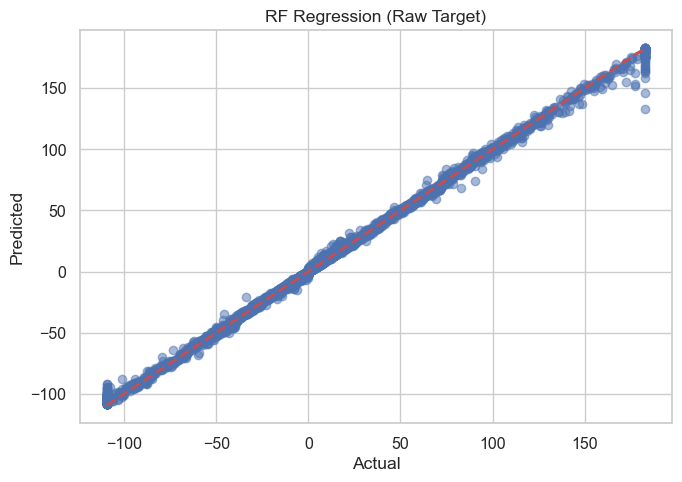

In [8]:
# ── 2.1 Train RF on raw regression target ───────────────────────────

print('='*60)

print('  Random Forest — Regression (Raw Target)')

print('='*60)



tkey = 'regression_raw'

data = prepare_target_splits(tkey)



if data:

    rf_raw = RandomForestRegressor(**RF_REG_PARAMS)

    rf_raw.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])



    y_pred = rf_raw.predict(data['X_test'])
    y_pred_train = rf_raw.predict(data['X_train'])
    train_metrics = evaluate_regression(data['y_train'], y_pred_train)
    metrics = evaluate_regression(data['y_test'], y_pred)

    print('Train metrics:', train_metrics)
    print('Test metrics:', metrics)





    plot_regression_results(data['y_test'], y_pred, 'RF Regression (Raw Target)')



    trained_models[tkey] = rf_raw

    summary_rows.append({'Target': tkey, 'Model': 'Regressor', **to_serializable(metrics)})

else:

    print(f'⚠️  Target "{tkey}" not available')

---

## 3. Random Forest for Regression — Log-Transformed Target (`target_log`)

We train a Random Forest to predict the **log-transformed** target value.

  Random Forest — Regression (Log Target)
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
Train metrics: {'MAE': 0.03261375305245991, 'MSE': 0.00290958056417243, 'RMSE': np.float64(0.053940528030159564), 'R2': 0.9995878693565801}
Test metrics: {'MAE': 0.03530534628396789, 'MSE': 0.003472939197961645, 'RMSE': np.float64(0.058931648525742474), 'R2': 0.9995021818712782}


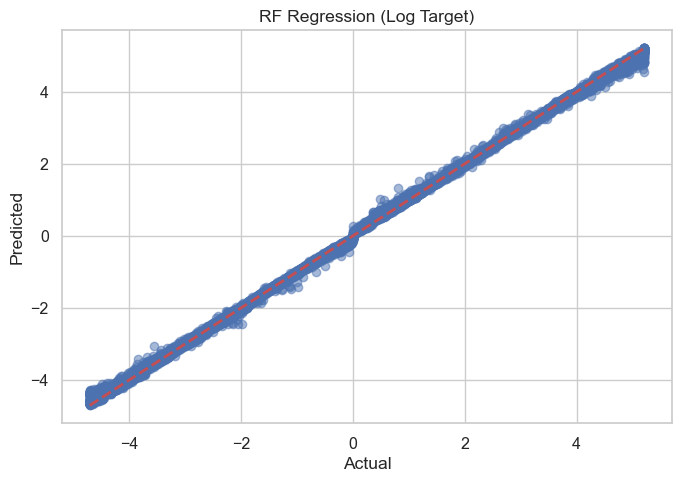

In [9]:
# ── 3.1 Train RF on log regression target ───────────────────────────

print('='*60)

print('  Random Forest — Regression (Log Target)')

print('='*60)



tkey = 'regression_log'

data = prepare_target_splits(tkey)



if data:

    rf_log = RandomForestRegressor(**RF_REG_PARAMS)

    rf_log.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])



    y_pred = rf_log.predict(data['X_test'])
    y_pred_train = rf_log.predict(data['X_train'])
    train_metrics = evaluate_regression(data['y_train'], y_pred_train)
    metrics = evaluate_regression(data['y_test'], y_pred)

    print('Train metrics:', train_metrics)
    print('Test metrics:', metrics)





    plot_regression_results(data['y_test'], y_pred, 'RF Regression (Log Target)')



    trained_models[tkey] = rf_log

    summary_rows.append({'Target': tkey, 'Model': 'Regressor', **to_serializable(metrics)})

else:

    print(f'⚠️  Target "{tkey}" not available')

---

## 4. Random Forest for Binary Classification (`target_binary`)

## 4.0 Random Forest Hyperparameter Configuration Comparison

This section evaluates five Random Forest configurations for the classification task by varying the number of trees (`n_estimators`) and maximum tree depth (`max_depth`). The goal is to identify the best-performing Random Forest setting before presenting the final model results.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

RF_CONFIGS = [
    {"label": "n=50, max_depth=None",  "n_estimators": 50,  "max_depth": None},
    {"label": "n=100, max_depth=None", "n_estimators": 100, "max_depth": None},
    {"label": "n=200, max_depth=None", "n_estimators": 200, "max_depth": None},
    {"label": "n=100, max_depth=10",   "n_estimators": 100, "max_depth": 10},
    {"label": "n=100, max_depth=20",   "n_estimators": 100, "max_depth": 20},
]

prep = prepare_target_splits("binary_classification")
rf_config_rows = []

if prep is not None:
    print("Returned keys from prepare_target_splits:", prep.keys())

    X_train = prep["X_train"]
    X_val   = prep["X_val"]
    X_test  = prep["X_test"]
    y_train = prep["y_train"]
    y_val   = prep["y_val"]
    y_test  = prep["y_test"]
    w_train = prep.get("w_train")
    w_val   = prep.get("w_val")
    w_test  = prep.get("w_test")
    imputer = prep.get("imputer")

    print("X_train shape:", X_train.shape)
    print("X_val shape:", X_val.shape)
    print("y_train distribution:", pd.Series(y_train).value_counts().to_dict())
    print("y_val distribution:", pd.Series(y_val).value_counts().to_dict())

    for cfg in RF_CONFIGS:
        print(f"\nRunning {cfg['label']}")

        model = RandomForestClassifier(
            n_estimators=cfg["n_estimators"],
            max_depth=cfg["max_depth"],
            random_state=42,
            n_jobs=-1,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced",
        )

        if w_train is not None:
            model.fit(X_train, y_train, sample_weight=w_train)
        else:
            model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        acc = accuracy_score(y_val, y_val_pred)
        prec = precision_score(y_val, y_val_pred, average="binary", zero_division=0)
        rec = recall_score(y_val, y_val_pred, average="binary", zero_division=0)
        f1 = f1_score(y_val, y_val_pred, average="binary", zero_division=0)

        train_acc = accuracy_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred, average="binary", zero_division=0)

        rf_config_rows.append({
            "Configuration": cfg["label"],
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "Train Accuracy": train_acc,
            "Train F1-Score": train_f1,
        })

    rf_config_df = pd.DataFrame(rf_config_rows)
    display(rf_config_df.round(4))

else:
    print("Target not available.")

   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
Returned keys from prepare_target_splits: dict_keys(['X_train', 'y_train', 'w_train', 'X_val', 'y_val', 'w_val', 'X_test', 'y_test', 'w_test', 'feature_names', 'target_col'])
X_train shape: (77455, 19)
X_val shape: (16597, 19)
y_train distribution: {1: 42496, 0: 34959}
y_val distribution: {1: 9065, 0: 7532}

Running n=50, max_depth=None

Running n=100, max_depth=None

Running n=200, max_depth=None

Running n=100, max_depth=10

Running n=100, max_depth=20


,Configuration,Accuracy,Precision,Recall,F1-Score,Train Accuracy,Train F1-Score
0,"n=50, max_depth=None",1.0,1.0,1.0,1.0,1.0,1.0
1,"n=100, max_depth=None",1.0,1.0,1.0,1.0,1.0,1.0
2,"n=200, max_depth=None",1.0,1.0,1.0,1.0,1.0,1.0
3,"n=100, max_depth=10",1.0,1.0,1.0,1.0,1.0,1.0
4,"n=100, max_depth=20",1.0,1.0,1.0,1.0,1.0,1.0


In [16]:
rf_report_df = rf_config_df.copy()
rf_report_df["Accuracy"] = (rf_report_df["Accuracy"] * 100).round(1).astype(str) + "%"
rf_report_df["Precision"] = (rf_report_df["Precision"] * 100).round(1).astype(str) + "%"
rf_report_df["Recall"] = (rf_report_df["Recall"] * 100).round(1).astype(str) + "%"
rf_report_df["F1-Score"] = rf_report_df["F1-Score"].round(3)

display(rf_report_df[["Configuration", "Accuracy", "Precision", "Recall", "F1-Score"]])

,Configuration,Accuracy,Precision,Recall,F1-Score
0,"n=50, max_depth=None",100.0%,100.0%,100.0%,1.0
1,"n=100, max_depth=None",100.0%,100.0%,100.0%,1.0
2,"n=200, max_depth=None",100.0%,100.0%,100.0%,1.0
3,"n=100, max_depth=10",100.0%,100.0%,100.0%,1.0
4,"n=100, max_depth=20",100.0%,100.0%,100.0%,1.0


We train a Random Forest to decide **yes/no** for the binary target.

In [17]:
feature_names = prep["feature_names"]
target_col = prep["target_col"]

print("Suspicious features:")
for f in feature_names:
    f_lower = f.lower()
    if any(word in f_lower for word in ["target", "label", "class", "outcome", "response"]):
        print("-", f)

Suspicious features:
- feat_eco3_target_mean


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

RF_CONFIGS = [
    {"label": "n=50, max_depth=None",  "n_estimators": 50,  "max_depth": None},
    {"label": "n=100, max_depth=None", "n_estimators": 100, "max_depth": None},
    {"label": "n=200, max_depth=None", "n_estimators": 200, "max_depth": None},
    {"label": "n=100, max_depth=10",   "n_estimators": 100, "max_depth": 10},
    {"label": "n=100, max_depth=20",   "n_estimators": 100, "max_depth": 20},
]

prep = prepare_target_splits("binary_classification")
rf_config_rows = []

if prep is not None:
    bad_keywords = ["target", "mean", "enc", "avg"]

    keep_idx = [i for i, f in enumerate(prep["feature_names"]) 
                if not any(k in f.lower() for k in bad_keywords)]

    filtered_features = [prep["feature_names"][i] for i in keep_idx]

    print("Using features:", filtered_features)

    # print("Original features:", feature_names)

    # # remove leaked feature
    # keep_idx = [i for i, f in enumerate(feature_names) if f != "feat_eco3_target_mean"]
    # filtered_feature_names = [feature_names[i] for i in keep_idx]

    # print("\nRemoved leaked feature: feat_eco3_target_mean")
    # print("Remaining features:", filtered_feature_names)

    X_train = prep["X_train"][:, keep_idx]
    X_val   = prep["X_val"][:, keep_idx]
    X_test  = prep["X_test"][:, keep_idx]

    y_train = prep["y_train"]
    y_val   = prep["y_val"]
    y_test  = prep["y_test"]

    w_train = prep.get("w_train")

    print("\nNew shapes after removing leaked feature:")
    print("X_train:", X_train.shape)
    print("X_val:", X_val.shape)
    print("X_test:", X_test.shape)

    for cfg in RF_CONFIGS:
        print(f"\nRunning {cfg['label']}")

        model = RandomForestClassifier(
            n_estimators=cfg["n_estimators"],
            max_depth=cfg["max_depth"],
            random_state=42,
            n_jobs=-1,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced",
        )

        if w_train is not None:
            model.fit(X_train, y_train, sample_weight=w_train)
        else:
            model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        acc = accuracy_score(y_val, y_val_pred)
        prec = precision_score(y_val, y_val_pred, average="binary", zero_division=0)
        rec = recall_score(y_val, y_val_pred, average="binary", zero_division=0)
        f1 = f1_score(y_val, y_val_pred, average="binary", zero_division=0)

        train_acc = accuracy_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred, average="binary", zero_division=0)

        rf_config_rows.append({
            "Configuration": cfg["label"],
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "Train Accuracy": train_acc,
            "Train F1-Score": train_f1,
        })

    rf_config_df = pd.DataFrame(rf_config_rows)
    display(rf_config_df.round(4))

else:
    print("Target not available.")

   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
Using features: ['EXPN.ha_scaled', 'LAT_scaled', 'LON_scaled', 'eco.EXPN.ha_scaled', 'feat_carbon_sink', 'feat_eco_state_ratio', 'feat_expanded_per_ha', 'feat_growth_share', 'feat_gs_ratio', 'feat_lat_bin', 'feat_lat_x_eco1', 'feat_log_magnitude', 'feat_lon_bin', 'state.EXPN.ha_scaled']

New shapes after removing leaked feature:
X_train: (77455, 14)
X_val: (16597, 14)
X_test: (16598, 14)

Running n=50, max_depth=None

Running n=100, max_depth=None

Running n=200, max_depth=None

Running n=100, max_depth=10

Running n=100, max_depth=20


,Configuration,Accuracy,Precision,Recall,F1-Score,Train Accuracy,Train F1-Score
0,"n=50, max_depth=None",1.0000,1.0,1.0000,1.0000,1.0,1.0
1,"n=100, max_depth=None",1.0000,1.0,1.0000,1.0000,1.0,1.0
2,"n=200, max_depth=None",0.9999,1.0,0.9999,0.9999,1.0,1.0
3,"n=100, max_depth=10",1.0000,1.0,1.0000,1.0000,1.0,1.0
4,"n=100, max_depth=20",1.0000,1.0,1.0000,1.0000,1.0,1.0


In [20]:
import numpy as np
import pandas as pd

prep = prepare_target_splits("binary_classification")
X_train = prep["X_train"]
y_train = prep["y_train"]
feature_names = prep["feature_names"]

# if you already filtered columns, use those filtered arrays/names instead
for i, f in enumerate(feature_names):
    corr = np.corrcoef(X_train[:, i], y_train)[0, 1]
    if np.isfinite(corr):
        print(f"{f}: {corr:.6f}")

   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
EXPN.ha_scaled: -0.039928
LAT_scaled: 0.155322
LON_scaled: 0.023163
eco.EXPN.ha_scaled: -0.054375
feat_carbon_sink: 1.000000
feat_eco3_target_mean: 0.247233
feat_eco_state_ratio: -0.057780
feat_enc_NA_L1CODE: 0.028882
feat_enc_NA_L3CODE: -0.026116
feat_enc_US_L4CODE: 0.028855
feat_enc_state: -0.011191
feat_expanded_per_ha: 0.525157
feat_growth_share: 0.565377
feat_gs_ratio: 0.005108
feat_lat_bin: 0.152311
feat_lat_x_eco1: 0.099794
feat_log_magnitude: 0.877212
feat_lon_bin: 0.020728
state.EXPN.ha_scaled: 0.087683


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# ------------------------------------------------------------
# Random Forest configuration comparison (binary classification)
# using only leakage-safe features
# ------------------------------------------------------------

RF_CONFIGS = [
    {"label": "n=50, max_depth=None",  "n_estimators": 50,  "max_depth": None},
    {"label": "n=100, max_depth=None", "n_estimators": 100, "max_depth": None},
    {"label": "n=200, max_depth=None", "n_estimators": 200, "max_depth": None},
    {"label": "n=100, max_depth=10",   "n_estimators": 100, "max_depth": 10},
    {"label": "n=100, max_depth=20",   "n_estimators": 100, "max_depth": 20},
]

safe_features = [
    "EXPN.ha_scaled",
    "LAT_scaled",
    "LON_scaled",
    "eco.EXPN.ha_scaled",
    "state.EXPN.ha_scaled",
    "feat_lat_bin",
    "feat_lon_bin",
    "feat_lat_x_eco1",
]

prep = prepare_target_splits("binary_classification")
rf_config_rows = []

if prep is not None:
    feature_names = prep["feature_names"]

    # keep only safe features
    keep_idx = [i for i, f in enumerate(feature_names) if f in safe_features]
    used_features = [feature_names[i] for i in keep_idx]

    print("=" * 70)
    print("Random Forest — 5 Configuration Comparison (Leakage-Safe Features)")
    print("=" * 70)
    print("Using safe features:", used_features)

    X_train = prep["X_train"][:, keep_idx]
    X_val   = prep["X_val"][:, keep_idx]
    X_test  = prep["X_test"][:, keep_idx]

    y_train = prep["y_train"]
    y_val   = prep["y_val"]
    y_test  = prep["y_test"]

    w_train = prep.get("w_train")

    print("\nShapes:")
    print("Train:", X_train.shape)
    print("Val  :", X_val.shape)
    print("Test :", X_test.shape)

    print("\nTarget distribution:")
    print("Train:", pd.Series(y_train).value_counts().to_dict())
    print("Val  :", pd.Series(y_val).value_counts().to_dict())
    print("Test :", pd.Series(y_test).value_counts().to_dict())

    for cfg in RF_CONFIGS:
        print(f"\nRunning {cfg['label']} ...")

        model = RandomForestClassifier(
            n_estimators=cfg["n_estimators"],
            max_depth=cfg["max_depth"],
            random_state=42,
            n_jobs=-1,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced",
        )

        if w_train is not None:
            model.fit(X_train, y_train, sample_weight=w_train)
        else:
            model.fit(X_train, y_train)

        # predictions
        y_train_pred = model.predict(X_train)
        y_val_pred   = model.predict(X_val)
        y_test_pred  = model.predict(X_test)

        # train metrics
        train_acc  = accuracy_score(y_train, y_train_pred)
        train_prec = precision_score(y_train, y_train_pred, average="binary", zero_division=0)
        train_rec  = recall_score(y_train, y_train_pred, average="binary", zero_division=0)
        train_f1   = f1_score(y_train, y_train_pred, average="binary", zero_division=0)

        # validation metrics
        val_acc  = accuracy_score(y_val, y_val_pred)
        val_prec = precision_score(y_val, y_val_pred, average="binary", zero_division=0)
        val_rec  = recall_score(y_val, y_val_pred, average="binary", zero_division=0)
        val_f1   = f1_score(y_val, y_val_pred, average="binary", zero_division=0)

        # test metrics
        test_acc  = accuracy_score(y_test, y_test_pred)
        test_prec = precision_score(y_test, y_test_pred, average="binary", zero_division=0)
        test_rec  = recall_score(y_test, y_test_pred, average="binary", zero_division=0)
        test_f1   = f1_score(y_test, y_test_pred, average="binary", zero_division=0)

        rf_config_rows.append({
            "Configuration": cfg["label"],

            "Train Accuracy": train_acc,
            "Train Precision": train_prec,
            "Train Recall": train_rec,
            "Train F1-Score": train_f1,

            "Val Accuracy": val_acc,
            "Val Precision": val_prec,
            "Val Recall": val_rec,
            "Val F1-Score": val_f1,

            "Test Accuracy": test_acc,
            "Test Precision": test_prec,
            "Test Recall": test_rec,
            "Test F1-Score": test_f1,
        })

    rf_config_df = pd.DataFrame(rf_config_rows)

    print("\nFull comparison table:")
    display(rf_config_df.round(4))

    # report-ready validation table
    rf_report_df = rf_config_df.copy()
    for col in [
        "Val Accuracy", "Val Precision", "Val Recall",
        "Test Accuracy", "Test Precision", "Test Recall"
    ]:
        rf_report_df[col] = (rf_report_df[col] * 100).round(1).astype(str) + "%"

    rf_report_df["Val F1-Score"] = rf_report_df["Val F1-Score"].round(3)
    rf_report_df["Test F1-Score"] = rf_report_df["Test F1-Score"].round(3)

    print("\nValidation report table:")
    display(rf_report_df[[
        "Configuration",
        "Val Accuracy",
        "Val Precision",
        "Val Recall",
        "Val F1-Score"
    ]])

    print("\nTest report table:")
    display(rf_report_df[[
        "Configuration",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1-Score"
    ]])

    # best configuration based on validation F1
    best_idx = rf_config_df["Val F1-Score"].idxmax()
    best_row = rf_config_df.loc[best_idx]

    print("\nBest configuration based on Validation F1:")
    print(best_row)

    # optional save
    rf_config_df.to_csv("outputs/reports/rf_safe_feature_config_comparison.csv", index=False)
    print("\nSaved: outputs/reports/rf_safe_feature_config_comparison.csv")

else:
    print("Target not available.")

   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
Random Forest — 5 Configuration Comparison (Leakage-Safe Features)
Using safe features: ['EXPN.ha_scaled', 'LAT_scaled', 'LON_scaled', 'eco.EXPN.ha_scaled', 'feat_lat_bin', 'feat_lat_x_eco1', 'feat_lon_bin', 'state.EXPN.ha_scaled']

Shapes:
Train: (77455, 8)
Val  : (16597, 8)
Test : (16598, 8)

Target distribution:
Train: {1: 42496, 0: 34959}
Val  : {1: 9065, 0: 7532}
Test : {1: 9086, 0: 7512}

Running n=50, max_depth=None ...

Running n=100, max_depth=None ...

Running n=200, max_depth=None ...

Running n=100, max_depth=10 ...

Running n=100, max_depth=20 ...

Full comparison table:


,Configuration,Train Accuracy,Train Precision,Train Recall,Train F1-Score,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,"n=50, max_depth=None",0.8480,0.8667,0.8543,0.8605,0.6848,0.7118,0.7106,0.7112,0.6827,0.7140,0.7014,0.7076
1,"n=100, max_depth=None",0.8506,0.8692,0.8567,0.8629,0.6843,0.7118,0.7090,0.7104,0.6844,0.7167,0.7001,0.7083
2,"n=200, max_depth=None",0.8529,0.8716,0.8584,0.8650,0.6854,0.7126,0.7104,0.7115,0.6842,0.7156,0.7024,0.7089
3,"n=100, max_depth=10",0.6978,0.7363,0.6999,0.7176,0.6730,0.7105,0.6770,0.6934,0.6725,0.7103,0.6785,0.6940
4,"n=100, max_depth=20",0.8216,0.8429,0.8293,0.8361,0.6872,0.7148,0.7109,0.7128,0.6828,0.7140,0.7015,0.7077



Validation report table:


,Configuration,Val Accuracy,Val Precision,Val Recall,Val F1-Score
0,"n=50, max_depth=None",68.5%,71.2%,71.1%,0.711
1,"n=100, max_depth=None",68.4%,71.2%,70.9%,0.710
2,"n=200, max_depth=None",68.5%,71.3%,71.0%,0.712
3,"n=100, max_depth=10",67.3%,71.1%,67.7%,0.693
4,"n=100, max_depth=20",68.7%,71.5%,71.1%,0.713



Test report table:


,Configuration,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,"n=50, max_depth=None",68.3%,71.4%,70.1%,0.708
1,"n=100, max_depth=None",68.4%,71.7%,70.0%,0.708
2,"n=200, max_depth=None",68.4%,71.6%,70.2%,0.709
3,"n=100, max_depth=10",67.2%,71.0%,67.9%,0.694
4,"n=100, max_depth=20",68.3%,71.4%,70.2%,0.708



Best configuration based on Validation F1:
Configuration      n=100, max_depth=20
Train Accuracy                0.821574
Train Precision               0.842949
Train Recall                  0.829302
Train F1-Score                0.836069
Val Accuracy                  0.687172
Val Precision                 0.714809
Val Recall                    0.710866
Val F1-Score                  0.712832
Test Accuracy                 0.682793
Test Precision                0.714014
Test Recall                   0.701519
Test F1-Score                 0.707711
Name: 4, dtype: object

Saved: outputs/reports/rf_safe_feature_config_comparison.csv


  Random Forest — Binary Classification
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
Train metrics: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'ROC_AUC': 1.0}
Test metrics: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'ROC_AUC': 1.0}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7512
           1       1.00      1.00      1.00      9086

    accuracy                           1.00     16598
   macro avg       1.00      1.00      1.00     16598
weighted avg       1.00      1.00      1.00     16598



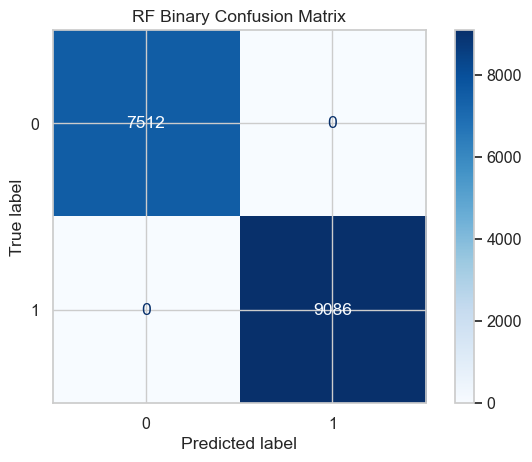

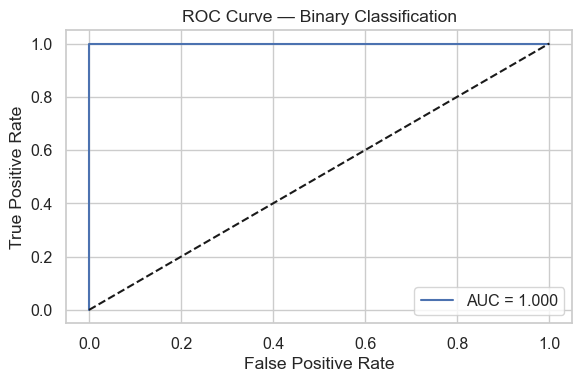

In [ ]:
# ── 4.1 Train RF on binary classification target ─────────────────────

print('='*60)

print('  Random Forest — Binary Classification')

print('='*60)



tkey = 'binary_classification'

data = prepare_target_splits(tkey)



if data:

    rf_bin = RandomForestClassifier(**RF_CLF_PARAMS)

    rf_bin.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])



    y_pred = rf_bin.predict(data['X_test'])

    y_proba = rf_bin.predict_proba(data['X_test'])[:, 1] if hasattr(rf_bin, 'predict_proba') else None
    y_pred_train = rf_bin.predict(data['X_train'])
    y_proba_train = rf_bin.predict_proba(data['X_train'])[:, 1] if hasattr(rf_bin, 'predict_proba') else None
    train_metrics = evaluate_classification(data['y_train'], y_pred_train, y_proba_train, average='binary')
    metrics = evaluate_classification(data['y_test'], y_pred, y_proba, average='binary')
    print('Train metrics:', train_metrics)
    print('Test metrics:', metrics)





    print('\nClassification Report:')

    print(classification_report(data['y_test'], y_pred, zero_division=0))

    plot_confusion(data['y_test'], y_pred, 'RF Binary Confusion Matrix')



    if y_proba is not None:

        fpr, tpr, _ = roc_curve(data['y_test'], y_proba)

        plt.figure(figsize=(6, 4))

        plt.plot(fpr, tpr, label=f'AUC = {metrics.get("ROC_AUC", 0):.3f}')

        plt.plot([0, 1], [0, 1], 'k--')

        plt.xlabel('False Positive Rate')

        plt.ylabel('True Positive Rate')

        plt.title('ROC Curve — Binary Classification')

        plt.legend()

        plt.tight_layout()

        plt.show()



    trained_models[tkey] = rf_bin

    summary_rows.append({'Target': tkey, 'Model': 'Classifier', **to_serializable(metrics)})

else:

    print(f'⚠️  Target "{tkey}" not available')

---

## 5. Random Forest for Multiclass Classification (`target_class3`)

We train a Random Forest to choose **1 of 3 classes** for the multiclass target.

  Random Forest — Multiclass Classification
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
Train metrics: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}
Test metrics: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5462
           1       1.00      1.00      1.00      5462
           2       1.00      1.00      1.00      5674

    accuracy                           1.00     16598
   macro avg       1.00      1.00      1.00     16598
weighted avg       1.00      1.00      1.00     16598



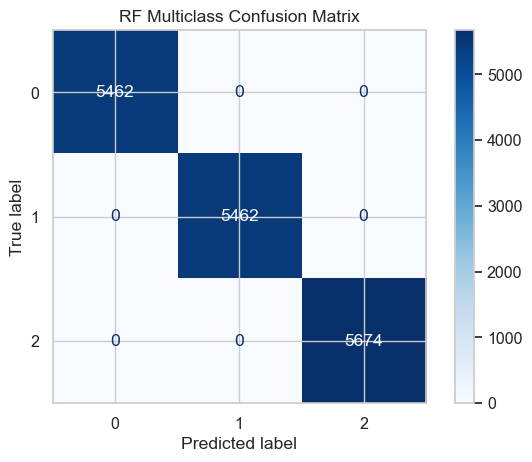

In [ ]:
# ── 5.1 Train RF on multiclass target ────────────────────────────────

print('='*60)

print('  Random Forest — Multiclass Classification')

print('='*60)



tkey = 'multiclass_3'

data = prepare_target_splits(tkey)



if data:

    rf_multi = RandomForestClassifier(**RF_CLF_PARAMS)

    rf_multi.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])



    y_pred = rf_multi.predict(data['X_test'])
    y_pred_train = rf_multi.predict(data['X_train'])
    train_metrics = evaluate_classification(data['y_train'], y_pred_train, average='macro')
    metrics = evaluate_classification(data['y_test'], y_pred, average='macro')
    print('Train metrics:', train_metrics)
    print('Test metrics:', metrics)





    print('\nClassification Report:')

    print(classification_report(data['y_test'], y_pred, zero_division=0))

    plot_confusion(data['y_test'], y_pred, 'RF Multiclass Confusion Matrix')



    trained_models[tkey] = rf_multi

    summary_rows.append({'Target': tkey, 'Model': 'Classifier', **to_serializable(metrics)})

else:

    print(f'⚠️  Target "{tkey}" not available')

---

## 6. Feature Importance Analysis

Feature importance shows which input clues are most helpful.

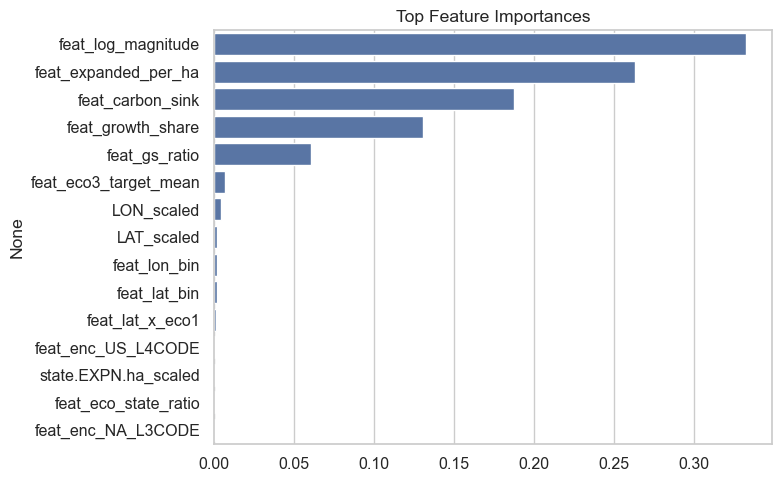

In [ ]:
# ── 6.1 Feature importances (use log regression if available) ────────

model_for_importance = trained_models.get('regression_log') or trained_models.get('regression_raw')



if model_for_importance is not None:

    plot_feature_importance(model_for_importance, FEATURES, top_n=15)

else:

    print('⚠️  No regression model available for feature importance')

---

## 7. Summary — All Targets

This table compares all model results in one place.

,Target,Model,MAE,MSE,RMSE,R2,Accuracy,Precision,Recall,F1,ROC_AUC
0,regression_raw,Regressor,0.6990,2.0481,1.4311,0.9985,NaN,NaN,NaN,NaN,NaN
1,regression_log,Regressor,0.0353,0.0035,0.0589,0.9995,NaN,NaN,NaN,NaN,NaN
2,binary_classification,Classifier,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0
3,multiclass_3,Classifier,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN


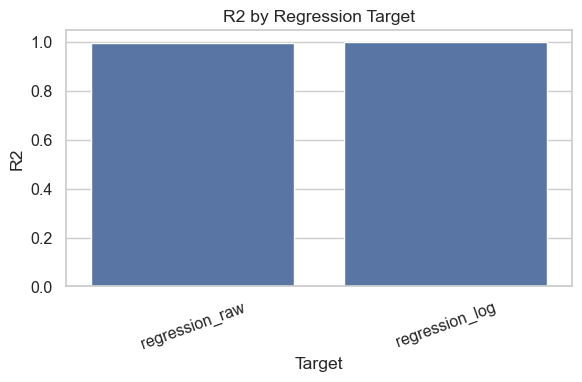

In [ ]:
# ── 7.1 Summary table ────────────────────────────────────────────────

if summary_rows:

    summary_df = pd.DataFrame(summary_rows)

    display(summary_df.round(4))



    # Simple comparison chart for regression metrics

    reg_df = summary_df[summary_df['Model'] == 'Regressor']

    if not reg_df.empty:

        plt.figure(figsize=(6, 4))

        sns.barplot(data=reg_df, x='Target', y='R2')

        plt.title('R2 by Regression Target')

        plt.xticks(rotation=20)

        plt.tight_layout()

        plt.show()

else:

    print('⚠️  No results to summarize')

---

## 8. Save Models & Reports

We save the trained models and metrics so you can use them later.

In [ ]:
# ── 8.1 Save trained models ──────────────────────────────────────────

for tkey, model in trained_models.items():

    model_path = os.path.join(MODELS_DIR, f'random_forest_{tkey}.joblib')

    joblib.dump(model, model_path)

    print(f'✅ Saved model: {model_path}')



# ── 8.2 Save metrics to JSON ─────────────────────────────────────────

if summary_rows:

    report_path = os.path.join(REPORTS_DIR, 'random_forest_metrics.json')

    with open(report_path, 'w') as f:

        json.dump(summary_rows, f, indent=2)

    print(f'✅ Saved metrics: {report_path}')

✅ Saved model: outputs\models\random_forest_regression_raw.joblib
✅ Saved model: outputs\models\random_forest_regression_log.joblib
✅ Saved model: outputs\models\random_forest_binary_classification.joblib
✅ Saved model: outputs\models\random_forest_multiclass_3.joblib
✅ Saved metrics: outputs\reports\random_forest_metrics.json


---

## 🏁 Summary

This notebook trained Random Forest models for **regression** and **classification**, generated evaluation plots, and saved metrics/models for reporting.